# Neural Network for Handwritten Digits Classification project using TensorFlow and Keras
Includes data loading, preprocessing, model building, training, evaluation, and visualization.

# Importing required libraries


In [5]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sn

# Checking the version of TensorFlow

In [6]:
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.18.0


# Loading the Dataset
Loading the MNIST dataset from TensorFlow

MNIST dataset contains 60,000 training images and 10,000 test images of handwritten digits

In [11]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

# Checking the shape of the dataset

In [16]:
print(f"Training data shape: {X_train.shape}, Test data shape: {X_test.shape}")

Training data shape: (60000, 28, 28), Test data shape: (10000, 28, 28)


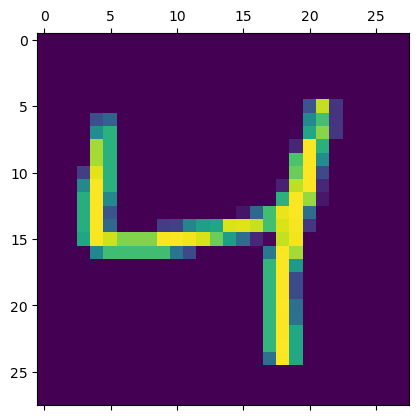

In [22]:
plt.matshow(X_train[2])

In [24]:
y_train[2]

4

# Data Preprocessing
Normalize the images to the range [0, 1] by dividing by 255, and reshape them for the neural network.

In [29]:
X_train = X_train / 255
X_test = X_test/ 255

In [31]:
X_train_flat = X_train.reshape(len(X_train), 28*28)
X_test_flat = X_test.reshape(len(X_test), 28*28)
X_test_flat.shape

(10000, 784)

# Visualizing the first 9 images in the training set

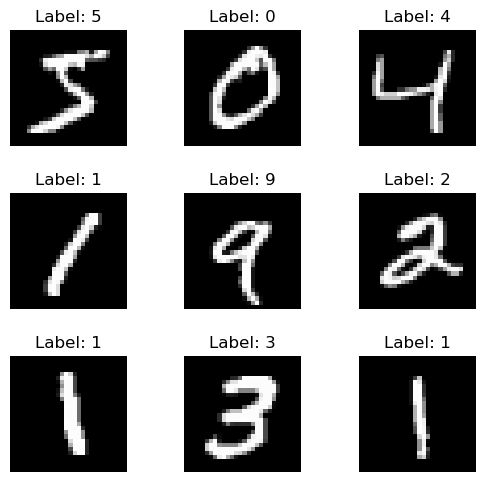

In [82]:
# Visualizing the first 9 images in the training set
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
axes = axes.ravel()

for i in np.arange(9):
    axes[i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis('off')

plt.subplots_adjust(wspace=0.5)
plt.show()


# Building the Neural Network
Simple neural network with a single dense layer that output 10 values
* Number of neurons = 10 - 10 possible classes
* 784 features = flattened 28x28 image
* loss = sparse_categorical_crossentropy - integer-labeled classes

In [33]:
model = keras.Sequential([
   keras.layers.Dense(
       10, 
       input_shape = (784,),
       activation='sigmoid') 
])
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])
model.fit(X_train_flat, y_train, epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 309us/step - accuracy: 0.8093 - loss: 0.7262
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 301us/step - accuracy: 0.9130 - loss: 0.3108
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 297us/step - accuracy: 0.9191 - loss: 0.2902
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 294us/step - accuracy: 0.9227 - loss: 0.2767
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 301us/step - accuracy: 0.9248 - loss: 0.2695


In [90]:
loss, accuracy = model.evaluate(X_test_flat, y_test)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 428us/step - accuracy: 0.9722 - loss: 0.0921
Test loss: 0.08148319274187088
Test accuracy: 0.9753999710083008


# Prediction the test set

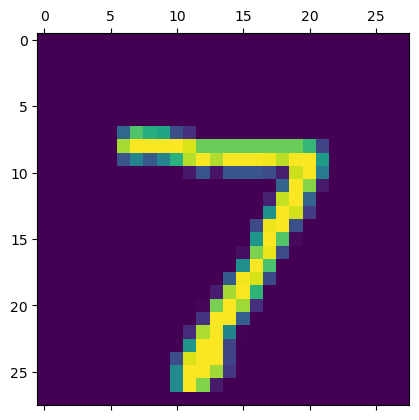

In [35]:
plt.matshow(X_test[0])

In [37]:
y_pred = model.predict(X_test_flat)
y_pred[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 226us/step


array([1.3150787e-02, 1.8043706e-07, 5.8959752e-02, 9.4162351e-01,
       1.6511017e-03, 9.5712066e-02, 1.4352252e-06, 9.9969292e-01,
       7.6277643e-02, 6.7545521e-01], dtype=float32)

Find the maximum value and print the index of that value

In [94]:
y_pred_labels = [np.argmax(i) for i in y_pred]
y_pred_labels[:5]

[7, 2, 1, 0, 4]

In [96]:
np.argmax(y_pred[0])

7

# Confusion Matrix

In [43]:
cm = tf.math.confusion_matrix(labels=y_test, predictions = y_pred_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 961,    0,    1,    2,    0,    4,    8,    2,    1,    1],
       [   0, 1108,    3,    2,    0,    2,    4,    2,   14,    0],
       [   7,    5,  932,   14,    9,    3,   13,   10,   33,    6],
       [   4,    0,   22,  913,    0,   25,    5,   12,   16,   13],
       [   1,    1,    3,    1,  894,    0,   16,    4,    9,   53],
       [  10,    2,    2,   30,    8,  782,   19,    6,   24,    9],
       [   8,    3,    5,    1,    7,    7,  924,    2,    1,    0],
       [   1,    5,   21,    6,    6,    0,    0,  940,    4,   45],
       [   8,    5,    8,   20,    9,   33,   11,    9,  849,   22],
       [  10,    5,    1,    8,   15,    7,    0,   12,    4,  947]],
      dtype=int32)>

Text(50.722222222222214, 0.5, 'Truth')

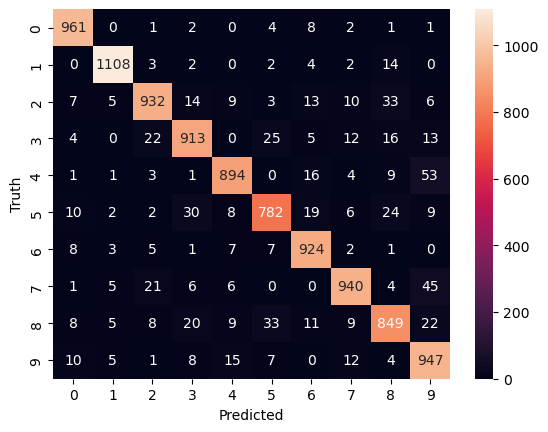

In [45]:
plt.figure(figure = (10, 7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

# Modifying the model
Adding one hidden layer

In [63]:
model = keras.Sequential([
   keras.layers.Dense(100, input_shape = (784,), activation='relu'), 
   keras.layers.Dense(10, activation='sigmoid') 
])

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

history = model.fit(X_train_flat, y_train, epochs = 5)
model.summary()

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 668us/step - accuracy: 0.8758 - loss: 0.4477
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 724us/step - accuracy: 0.9616 - loss: 0.1321
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 732us/step - accuracy: 0.9742 - loss: 0.0863
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 665us/step - accuracy: 0.9809 - loss: 0.0642
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 716us/step - accuracy: 0.9859 - loss: 0.0498


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,532 (931.77 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 159,022 (621.18 KB)

In [103]:
loss, accuracy = model.evaluate(X_test_flat, y_test)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 387us/step - accuracy: 0.9722 - loss: 0.0921
Test loss: 0.08148319274187088
Test accuracy: 0.9753999710083008


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 283us/step


Text(50.722222222222214, 0.5, 'Truth')

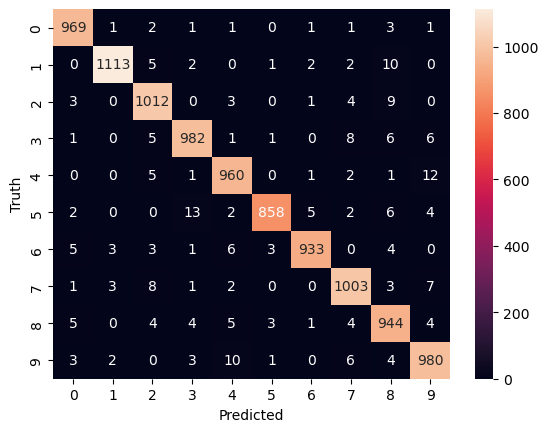

In [105]:
y_pred = model.predict(X_test_flat)
y_pred_labels = [np.argmax(i) for i in y_pred]
cm = tf.math.confusion_matrix(labels=y_test, predictions = y_pred_labels)

plt.figure(figure = (10, 7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

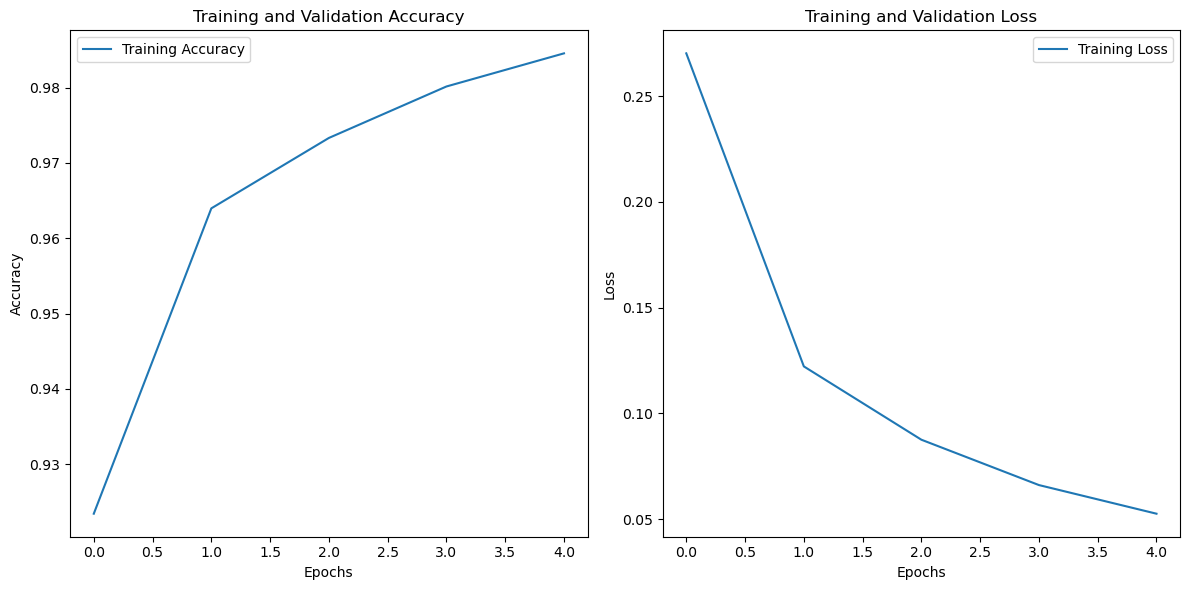

In [74]:
# Plotting training and validation accuracy
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


#  Misclassified Examples
Misclassified examples along with their predicted and actual labels.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 278us/step


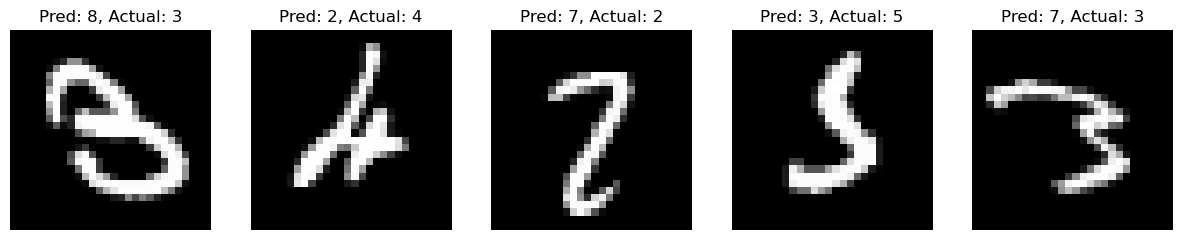

In [71]:
y_pred = model.predict(X_test_flat)
y_pred_classes = np.argmax(y_pred, axis=1)
misclassified_idx = np.where(y_pred_classes != y_test)[0]

# Displaying first 5 misclassified examples
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for i, idx in enumerate(misclassified_idx[:5]):
    axes[i].imshow(X_test_flat[idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Pred: {y_pred_classes[idx]}, Actual: {y_test[idx]}")
    axes[i].axis('off')

plt.show()
